In [1]:
!nvidia-smi

Thu May 21 21:37:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:3A:00.0 Off |                    0 |
| N/A   28C    P0             38W /  300W |       1MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/ocean/projects/asc170022p/mtragoza/lung-project/notebooks/copdgene'

In [3]:
import sys, os
sys.path.append(os.environ['LP'])
import project
from project.core.utils import pprint

# Clinical metadata

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
shared_root = '/ocean/projects/asc170022p/shared/Data/COPDGene'
private_root = '/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene'

In [34]:
import project.datasets.copdgene
dataset_cls = project.datasets.copdgene.COPDGeneDataset
ds = dataset_cls(shared_root)
ds

project.datasets.copdgene.COPDGeneDataset('/ocean/projects/asc170022p/shared/Data/COPDGene')

In [35]:
ds.load_metadata()
ds._metadata

,ccenter,distwalked,O2_suppl_6MW,Walk_Course,Walk_Limit,WalkSymp_BackPain,WalkSymp_JointPain,WalkSymp_Legs_Fatigue,WalkSymp_ShortnessBreath,QA_CalciumCalPad,...,pre_FEF2575,ATS_ERS,deltaFEV1,deltaFVC,BDR_pct_FEV1,BDR_pct_FVC,BDR,NewGOLD_SGRQ,Visit_Year,RandomGroupCode
sid,,,,,,,,,,,,,,,,,,,,,
10002K,BWH,978.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0.149,6.0,-0.021,0.012,-3.392569,0.632244,0.0,D1,2007,9.0
10004O,BWH,1166.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0.331,5.0,0.175,0.159,17.676768,5.117477,0.0,D1,2007,7.0
10005Q,NJC,1765.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,...,3.156,0.0,-0.257,-0.171,-8.086847,-4.300805,0.0,A,2008,5.0
10006S,BWH,1147.0,2.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0.295,4.0,-0.010,0.174,-0.770416,6.109551,0.0,B,2008,10.0
10008W,NJC,1305.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,...,2.286,0.0,-0.094,-0.191,-3.321555,-5.094692,0.0,A,2008,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26180S,HAR,300.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.493,0.0,0.144,-0.012,7.912088,-0.497719,0.0,B,2011,6.0
26181U,UAB,636.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.477,5.0,-0.084,-0.038,-4.976303,-1.285086,0.0,D1,2011,8.0
26182W,PIT,1355.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.268,0.0,0.089,0.192,5.870712,9.701870,0.0,B,2011,4.0


In [16]:
# select columns for visualization

subj_col_name = 'sid'     # subject ID
site_col_name = 'ccenter' # clinical site name
kern_col_name = 'kernel'  # reconstruction kernel

emph_cat_col_name = 'Emphysema'       # categorical emphysema variable
emph_pct_col_name = 'pctEmph'         # percent emphysema using VIDA
emph_pct2_col_name = 'pctEmph_Slicer' # percent emphysema using Slicer

fev_col_name = 'FEV1pp_utah'       # forced expiratory volume in 1 second
fvc_col_name = 'FVCpp_utah'        # forced vital capacity percent predicted
fev_fvc_col_name = 'FEV1_FVC_utah' # ratio of FEV1 to FVCpp

gold_col_name = 'finalGold' # GOLD score (categorical)

selected_columns = [
    #subj_col_name,
    site_col_name,
    kern_col_name,
    emph_cat_col_name,
    emph_pct_col_name,
    emph_pct2_col_name,
    fev_col_name,
    fvc_col_name,
    fev_fvc_col_name,
    gold_col_name,
]

df = ds._metadata[selected_columns].dropna()
df

,ccenter,kernel,Emphysema,pctEmph,pctEmph_Slicer,FEV1pp_utah,FVCpp_utah,FEV1_FVC_utah,finalGold
sid,,,,,,,,,
10005Q,NJC,STD,0,0.9819,0.8783,112.3,114.6,0.77,0.0
10006S,BWH,STD,1,14.1939,13.7448,51.7,93.3,0.43,2.0
10011L,BWH,STD,0,2.3425,2.2143,72.2,82.9,0.66,2.0
10013P,BWH,STD,1,9.9594,9.4883,61.4,106.6,0.44,2.0
10017X,BWH,STD,1,36.4779,35.8757,80.6,104.9,0.57,1.0
...,...,...,...,...,...,...,...,...,...
26180S,HAR,STD,0,0.1768,0.1710,90.9,87.6,0.82,0.0
26181U,UAB,STD,1,11.9066,11.6736,46.0,64.6,0.55,3.0
26182W,PIT,STD,0,0.5064,0.4673,81.5,86.5,0.74,0.0


In [17]:
# create derived columns

emph_cat2_col_name = 'catEmph'

derived_columns = [
    emph_cat2_col_name
]
final_columns = selected_columns + derived_columns

df[emph_cat2_col_name] = pd.cut(
    df[emph_pct_col_name],
    bins=[0, 5, 10, 20, 100],
    labels=['normal', 'mild', 'moderate', 'severe']
)
df

,ccenter,kernel,Emphysema,pctEmph,pctEmph_Slicer,FEV1pp_utah,FVCpp_utah,FEV1_FVC_utah,finalGold,catEmph
sid,,,,,,,,,,
10005Q,NJC,STD,0,0.9819,0.8783,112.3,114.6,0.77,0.0,normal
10006S,BWH,STD,1,14.1939,13.7448,51.7,93.3,0.43,2.0,moderate
10011L,BWH,STD,0,2.3425,2.2143,72.2,82.9,0.66,2.0,normal
10013P,BWH,STD,1,9.9594,9.4883,61.4,106.6,0.44,2.0,mild
10017X,BWH,STD,1,36.4779,35.8757,80.6,104.9,0.57,1.0,severe
...,...,...,...,...,...,...,...,...,...,...
26180S,HAR,STD,0,0.1768,0.1710,90.9,87.6,0.82,0.0,normal
26181U,UAB,STD,1,11.9066,11.6736,46.0,64.6,0.55,3.0,moderate
26182W,PIT,STD,0,0.5064,0.4673,81.5,86.5,0.74,0.0,normal


In [18]:
df[site_col_name].unique()

array(['NJC', 'BWH', 'UIA', 'MSM', 'HAR', 'JHU', 'BAY', 'UAB', 'COL',
       'TXS', 'USD', 'HPR', 'TEM', 'FAL', 'PIT', 'DUK', 'UMC', 'UMN',
       'HVA', 'AVA', 'MVA'], dtype=object)

In [19]:
# descriptive statistics
df[final_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Emphysema,8769.0,0.430950,0.817830,0.0000,0.0000,0.0000,1.0000,3.0000
pctEmph,8769.0,6.428300,9.827504,0.0065,0.6703,2.1704,7.1353,61.4671
pctEmph_Slicer,8769.0,6.179283,9.647653,0.0037,0.5991,2.0090,6.7185,61.9135
FEV1pp_utah,8769.0,77.085004,25.462290,9.5000,61.0000,81.3000,95.6000,159.9000
FVCpp_utah,8769.0,87.497685,18.086121,22.6000,76.0000,88.2000,99.5000,176.2000
FEV1_FVC_utah,8769.0,0.669587,0.161173,0.1500,0.5900,0.7200,0.7900,1.0000
finalGold,8769.0,0.877865,1.465548,-2.0000,0.0000,0.0000,2.0000,4.0000


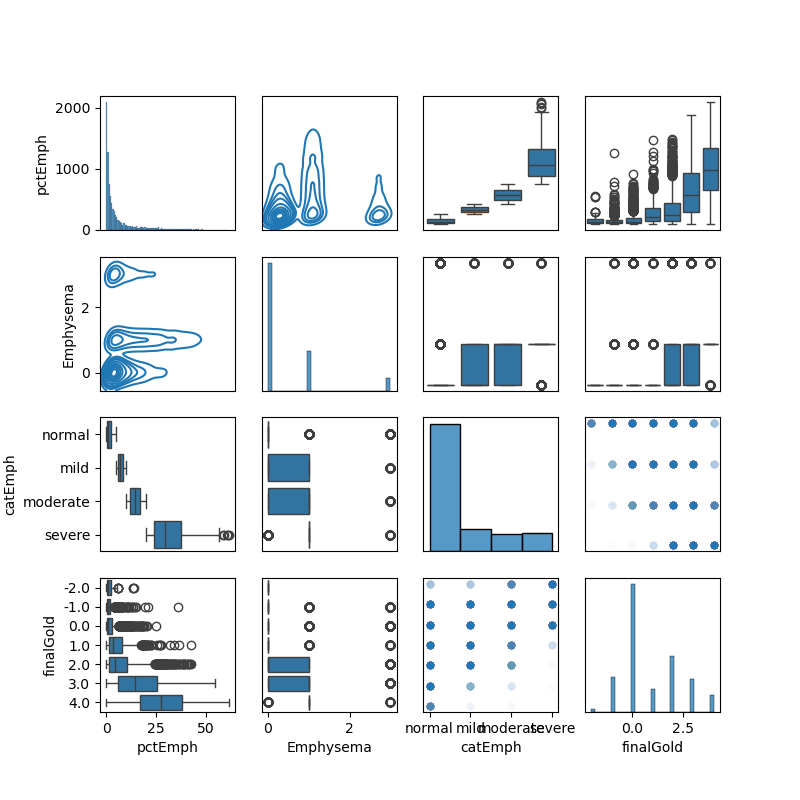

In [24]:
# pair plot of selected columns

plot_columns = ['pctEmph', 'Emphysema', 'catEmph', 'finalGold']
is_numeric = [True, True, False, False, False]

n_cols = len(plot_columns)
ax_height = 2
ax_width  = 2
alpha = 0.01

fig, ax = plt.subplots(n_cols, n_cols, figsize=(n_cols * ax_height, n_cols * ax_width))

for i, col_i in enumerate(plot_columns):
    for j, col_j in enumerate(plot_columns):
        
        # plot joint distribution
        if i == j:
            sns.histplot(df, x=col_i, ax=ax[i,j])
        elif is_numeric[i] and is_numeric[j]:
            sns.kdeplot(df, x=col_j, y=col_i, ax=ax[i,j])
        elif is_numeric[i]:
            sns.boxplot(df, x=col_j, y=col_i, orient='v', ax=ax[i,j])
        elif is_numeric[j]:
            sns.boxplot(df, x=col_j, y=col_i, orient='h', ax=ax[i,j])
        else:
            sns.scatterplot(df, x=col_j, y=col_i, alpha=alpha, ax=ax[i,j])

        if j == 0:
            ax[i,j].set_ylabel(col_i)
        else:
            ax[i,j].yaxis.set_visible(False)

        if i + 1 == len(plot_columns):
            ax[i,j].set_xlabel(col_j)
        else:
            ax[i,j].xaxis.set_visible(False)


/var/tmp/ipykernel_23019/1627140903.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


<Axes: xlabel='pctEmph', ylabel='pctEmph_Slicer'>

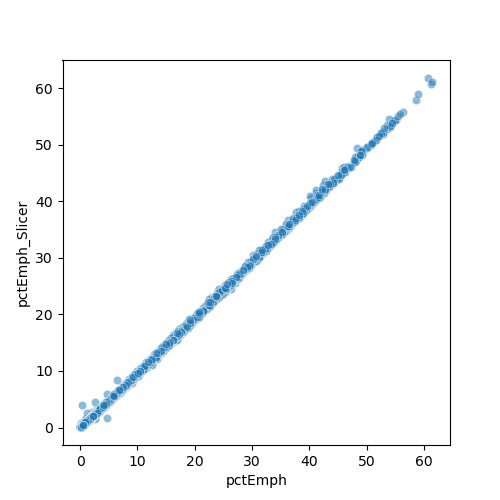

In [25]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(
    df,
    x=emph_pct_col_name,
    y=emph_pct2_col_name,
    palette='bright',
    alpha=0.5
)

<Axes: xlabel='pctEmph', ylabel='Emphysema'>

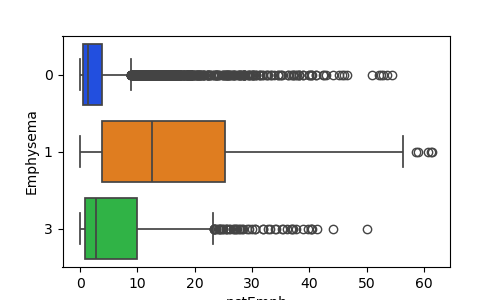

In [26]:
# plot distribution of percent emphysema x emphysema indicator
fig, ax = plt.subplots(figsize=(5,3))
sns.boxplot(
    df,
    x=emph_pct_col_name,
    y=emph_cat_col_name,
    hue=emph_cat_col_name,
    legend=False,
    orient='h',
    palette='bright',
    linewidth=1.25
)

In [27]:
df.groupby(emph_cat_col_name)[[emph_pct_col_name]].describe()

pctEmph                                                              \
            count       mean        std     min       25%      50%        75%   
Emphysema                                                                       
0          6228.0   3.426938   5.563375  0.0065  0.521575   1.4141   3.836625   
1          1922.0  15.917881  13.887227  0.0290  3.759200  12.4969  25.277125   
3           619.0   7.160943   9.355374  0.0285  0.903750   2.7198   9.853900   

                    
               max  
Emphysema           
0          54.5034  
1          61.4671  
3          49.9994

<Axes: xlabel='pctEmph', ylabel='pctEmph_Slicer'>

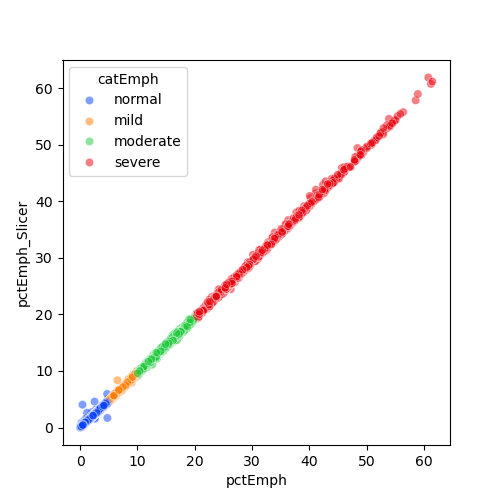

In [28]:
# plot distribution of percent emphysema x percent emphysema (Slicer) x categorical
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(
    df,
    x=emph_pct_col_name,
    y=emph_pct2_col_name,
    hue=emph_cat2_col_name,
    palette='bright',
    alpha=0.5
)

<Axes: xlabel='pctEmph', ylabel='catEmph'>

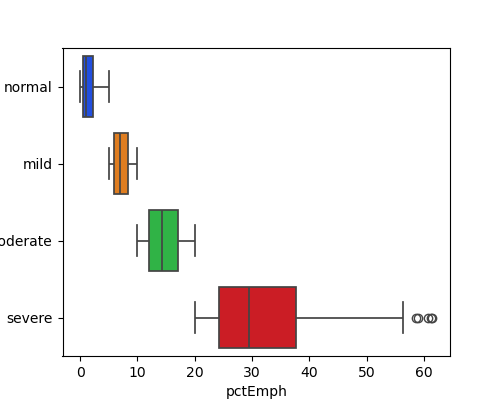

In [29]:
# plot distribution of percent emphysema x categorical emphysema
fig, ax = plt.subplots(figsize=(5,4))
sns.boxplot(
    df,
    x=emph_pct_col_name,
    y=emph_cat2_col_name,
    hue=emph_cat2_col_name,
    legend=False,
    orient='h',
    palette='bright',
    linewidth=1.25
)

In [30]:
df.groupby(emph_cat2_col_name)[[emph_pct_col_name]].describe()

/var/tmp/ipykernel_23019/2127130645.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(emph_cat2_col_name)[[emph_pct_col_name]].describe()


pctEmph                                                     \
           count       mean       std      min        25%       50%   
catEmph                                                               
normal    6004.0   1.501735  1.304045   0.0065   0.442675   1.04085   
mild      1056.0   7.105295  1.430290   5.0004   5.856825   6.87890   
moderate   831.0  14.543143  2.921632  10.0050  11.967500  14.34570   
severe     878.0  31.622775  8.877138  20.0083  24.250150  29.45750   

                              
                75%      max  
catEmph                       
normal     2.305575   4.9985  
mild       8.305250   9.9888  
moderate  17.086450  19.9899  
severe    37.588575  61.4671

<Axes: xlabel='pctEmph', ylabel='finalGold'>

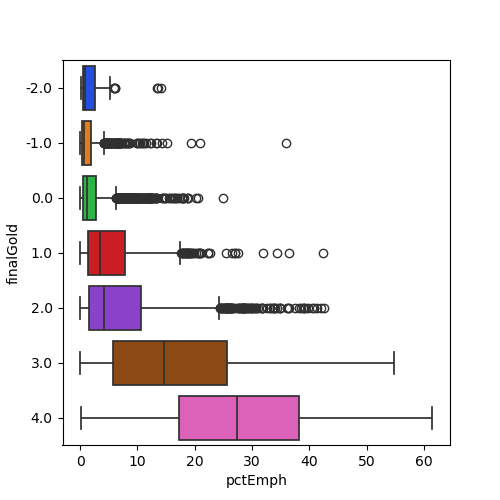

In [31]:
# plot distribution of GOLD score x percent emphysema
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(
    df,
    x=emph_pct_col_name,
    y=gold_col_name,
    hue=gold_col_name,
    legend=False,
    orient='h',
    palette='bright',
    linewidth=1.25,
)

In [32]:
df.groupby(gold_col_name)[[emph_pct_col_name]].describe()

pctEmph                                                     \
            count       mean        std     min        25%       50%   
finalGold                                                              
-2.0        103.0   1.989315   2.589436  0.0747   0.496800   0.85520   
-1.0       1041.0   1.540240   2.414525  0.0065   0.290600   0.71210   
 0.0       3797.0   2.153543   2.662509  0.0130   0.472100   1.12770   
 1.0        687.0   5.452516   5.747787  0.0451   1.348650   3.54590   
 2.0       1668.0   7.500553   8.085869  0.0286   1.590450   4.24030   
 3.0        970.0  16.823912  12.576195  0.0481   5.818575  14.70065   
 4.0        503.0  27.452229  14.270381  0.1502  17.246650  27.33220   

                               
                 75%      max  
finalGold                      
-2.0        2.599250  14.1338  
-1.0        1.832700  35.9520  
 0.0        2.818900  24.9841  
 1.0        7.834700  42.3733  
 2.0       10.695875  42.6116  
 3.0       25.577325  54.7645  
 4.0       38.231200  61.4671

(0.0, 1.0)

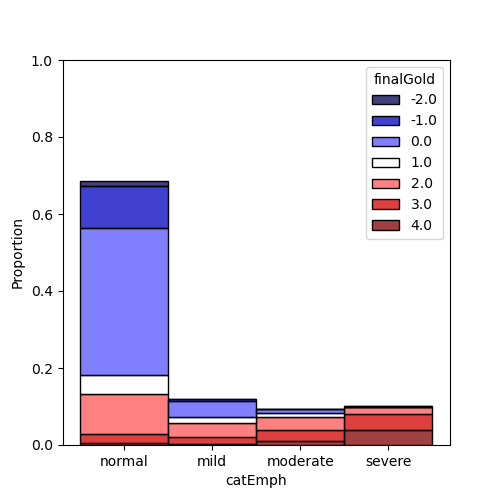

In [33]:
# plot distribution of GOLD score x emphysema category
fig, ax = plt.subplots(figsize=(5,5))
sns.histplot(
    df,
    x=emph_cat2_col_name,
    hue=gold_col_name,
    multiple='stack',
    palette='seismic',
    stat='proportion'
)
ax.set_ylim(0, 1)

(0.0, 160.0)

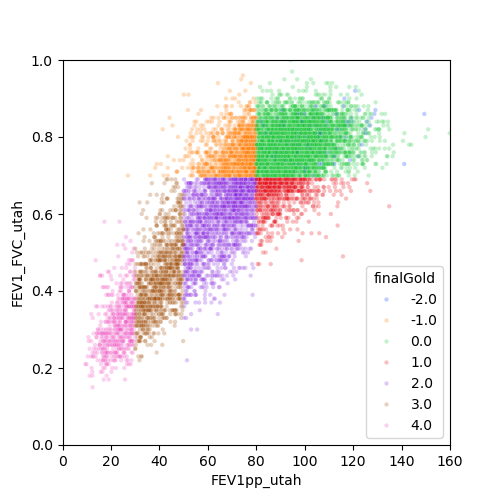

In [34]:
# plot distribution of FEV1/FVC x FEV1pp x GOLD score
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(
    df,
    x=fev_col_name,
    y=fev_fvc_col_name,
    hue=gold_col_name,
    palette='bright',
    alpha=0.25,
    s=10,
    ax=ax
)
ax.set_ylim(0, 1)
ax.set_xlim(0, 160)

(0.0, 160.0)

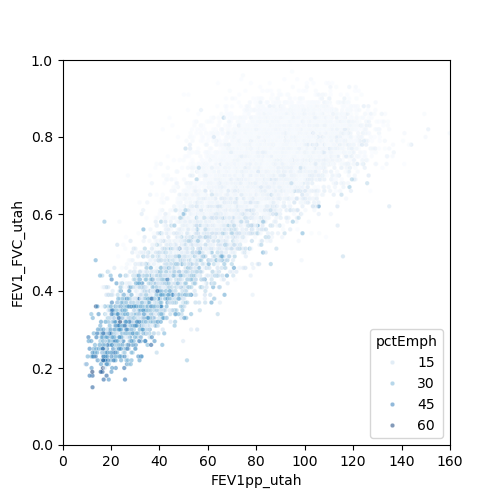

In [35]:
# plot distribution of FEV1/FVC x FEV1pp x percent emphysema
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(
    df,
    x=fev_col_name,
    y=fev_fvc_col_name,
    hue=emph_pct_col_name,
    palette='Blues',
    alpha=0.5,
    s=10
)
ax.set_ylim(0, 1)
ax.set_xlim(0, 160)

(0.0, 160.0)

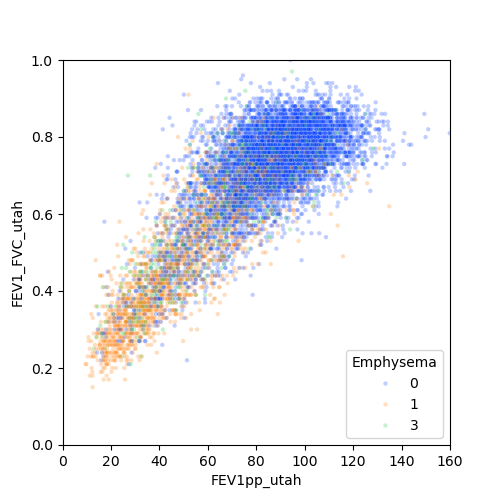

In [36]:
# plot distribution of FEV1/FVC x FEV1pp x emphysema variable
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(
    df,
    x=fev_col_name,
    y=fev_fvc_col_name,
    hue=emph_cat_col_name,
    palette='bright',
    alpha=0.25,
    s=10
)
ax.set_ylim(0, 1)
ax.set_xlim(0, 160)

(0.0, 160.0)

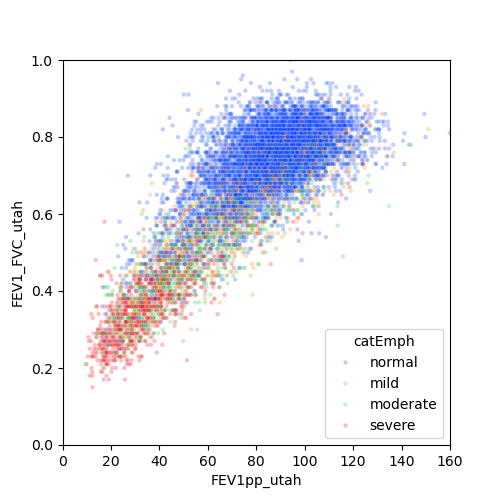

In [37]:
# plot distribution of FEV1/FVC x FEV1pp x emphysema category
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(
    df,
    x=fev_col_name,
    y=fev_fvc_col_name,
    hue=emph_cat2_col_name,
    palette='bright',
    alpha=0.25,
    s=10
)
ax.set_ylim(0, 1)
ax.set_xlim(0, 160)

In [38]:
df.groupby([emph_cat2_col_name, gold_col_name]).count().unstack()

/var/tmp/ipykernel_23019/1144864893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([emph_cat2_col_name, gold_col_name]).count().unstack()


ccenter                                kernel             ...  \
finalGold    -2.0 -1.0   0.0  1.0  2.0  3.0  4.0   -2.0 -1.0   0.0  ...   
catEmph                                                             ...   
normal         94  976  3349  429  907  213   36     94  976  3349  ...   
mild            6   50   368  141  314  146   31      6   50   368  ...   
moderate        3   13    77   99  297  246   96      3   13    77  ...   
severe          0    2     3   18  150  365  340      0    2     3  ...   

          FVCpp_utah           FEV1_FVC_utah                                 
finalGold        2.0  3.0  4.0          -2.0 -1.0   0.0  1.0  2.0  3.0  4.0  
catEmph                                                                      
normal           907  213   36            94  976  3349  429  907  213   36  
mild             314  146   31             6   50   368  141  314  146   31  
moderate         297  246   96             3   13    77   99  297  246   96  
severe           150  365  340             0    2     3   18  150  365  340  

[4 rows x 56 columns]

In [44]:
assert df.shape == (8769, 10), df.shape

# Validation and stratified sampling

In [45]:
# get subject ids that have valid image pair
valid_subjects = set()

def is_valid_image(path):
    import nibabel as nib
    try:
        nifti = nib.load(path)
        print(nifti.shape, nifti.header.get_zooms())
    except Exception as e:
        print(e)
        return False
    return True

for sid, row in df.iterrows():
    print(sid, row.ccenter, row.kernel)
    if row.kernel not in {'STD', '.'}:
        continue
    ee_image_path = ds.source_path(sid, 'Phase-1', 'EXP', 'image')
    ei_image_path = ds.source_path(sid, 'Phase-1', 'INSP', 'image')

    if is_valid_image(ee_image_path) and is_valid_image(ei_image_path):
        valid_subjects.add(sid)

len(valid_subjects)

10005Q NJC STD



KeyboardInterrupt

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x14dce69d60d0>>
Traceback (most recent call last):
  File "/ocean/projects/asc170022p/mtragoza/mambaforge/envs/warp/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [65]:
df_valid = df[
    (df.index.isin(valid_subjects)) &
    (df[gold_col_name] != -2)
]
df_valid.shape

(8112, 10)

In [66]:
df_sampled = df_valid.groupby([emph_cat2_col_name], observed=True).sample(250, random_state=0)
df_sampled

,ccenter,kernel,Emphysema,pctEmph,pctEmph_Slicer,FEV1pp_utah,FVCpp_utah,FEV1_FVC_utah,finalGold,catEmph
sid,,,,,,,,,,
16514P,TEM,STD,0,0.3373,0.3147,77.6,88.9,0.71,-1.0,normal
20748Q,UAB,STD,0,3.6045,3.4085,73.2,75.8,0.75,-1.0,normal
11007Z,USD,STD,0,0.3126,0.2867,66.7,108.0,0.47,2.0,normal
14771Z,HPR,STD,0,0.3160,0.2948,94.1,97.0,0.73,0.0,normal
13651K,UIA,STD,0,2.0807,1.9551,85.1,88.0,0.75,0.0,normal
...,...,...,...,...,...,...,...,...,...,...
20519B,DUK,STD,1,30.1942,29.6440,19.9,69.2,0.22,4.0,severe
12294H,UAB,STD,1,40.3908,39.5845,43.3,86.0,0.37,3.0,severe
23123R,TEM,STD,0,23.6838,22.7617,42.8,72.7,0.45,3.0,severe


In [103]:
sampled_ids = list(sorted(df_sampled.index.unique()))
sampled_ids

['10017X',
 '10020M',
 '10031R',
 '10049K',
 '10056H',
 '10081G',
 '10096T',
 '10114V',
 '10124Y',
 '10127E',
 '10130T',
 '10153F',
 '10155J',
 '10179X',
 '10181K',
 '10196X',
 '10211T',
 '10212V',
 '10213X',
 '10217F',
 '10227I',
 '10233D',
 '10245K',
 '10261I',
 '10265Q',
 '10301U',
 '10314D',
 '10328O',
 '10332F',
 '10367Y',
 '10372R',
 '10395D',
 '10426O',
 '10432J',
 '10458B',
 '10469G',
 '10478H',
 '10481W',
 '10490X',
 '10502E',
 '10503G',
 '10507O',
 '10512H',
 '10523M',
 '10524O',
 '10539B',
 '10552T',
 '10560S',
 '10561U',
 '10564A',
 '10566E',
 '10567G',
 '10568I',
 '10571X',
 '10572Z',
 '10624S',
 '10634V',
 '10635X',
 '10641S',
 '10646C',
 '10663C',
 '10679R',
 '10699X',
 '10705S',
 '10709A',
 '10724W',
 '10728E',
 '10736D',
 '10761C',
 '10794R',
 '10806Y',
 '10815Z',
 '10817D',
 '10829K',
 '10842C',
 '10843E',
 '10849Q',
 '10880K',
 '10883Q',
 '10887Y',
 '10888A',
 '10908G',
 '10919L',
 '10947Q',
 '10961K',
 '10973R',
 '10975V',
 '10990R',
 '11005V',
 '11007Z',
 '11027F',

In [100]:
# save sampled subjects to new data file
df_sampled.to_csv('../../data/COPDGene/sample1000_2025-05-21.csv', index=True)

# Transferring sampled data

In [12]:
import shutil

ds1 = dataset_cls(shared_root)
ds2 = dataset_cls(private_root)
asset_type = 'json'

for i, sid in enumerate(sampled_ids):
    print(f'[{i+1}/{len(sampled_ids)}] Copying {asset_type} files for subject {sid}')
    for state in ['EXP', 'INSP']:
        src_path = ds1.source_path(sid, 'Phase-1', state, asset_type)
        dst_path = ds2.source_path(sid, 'Phase-1', state, asset_type)
        shutil.copyfile(src_path, dst_path)


NameError: name 'examples' is not defined

# Spatial metadata

In [36]:
%autoreload
ds = dataset_cls(private_root)
ds

project.datasets.copdgene.COPDGeneDataset('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene')

In [41]:
examples = ds.list_examples(
    subjects='../../data/COPDGene/sample1000_2025-05-21.csv',
    state_pairs=[('EXP', 'INSP')]
)
len(examples)

1000

In [42]:
project.core.utils.pprint(examples[0], 4, 20)

Example()
├── dataset:  'COPDGene'
├── subject:  '16514P'
├── variant:  None
├── paths:    dict(len=3)
|   ├── 'ref_state':  dict(len=2)
|   |   ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz')
|   |   └── 'source_json':  PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.json')
|   ├── 'init_state': dict(len=2)
|   |   ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz')
|   |   └── 'source_json':  PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.json')
|   └── 'curr_state': dict(len=2)
|       ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.

In [43]:
ex = examples[0]

image0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
print(image0.shape)
print(image0.affine)

json0 = project.core.fileio.load_json(ex.paths['init_state']['source_json'])
json0

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
(512, 512, 537)
[[  -0.71875    -0.          0.        167.640625]
 [   0.          0.71875     0.         -6.640625]
 [   0.          0.          0.5      -319.      ]
 [   0.          0.          0.          1.      ]]
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.json


{'Modality': 'CT',
 'Manufacturer': 'Siemens',
 'ManufacturersModelName': 'Sensation_16',
 'InstitutionName': 'TEMPLE_UNIV._HOSP._-_BOYER_PAVILION',
 'InstitutionAddress': 'North_Broad_Street_Philadelphia_27dc10_Philadelphia_US',
 'DeviceSerialNumber': '51810',
 'StationName': 'CT51810',
 'BodyPartExamined': 'CHEST',
 'PatientPosition': 'HFS',
 'SoftwareVersions': 'syngo_CT_2007S',
 'SeriesDescription': '16514P_EXP_STD_TEM_COPD',
 'ProtocolName': '6_COPD_GENE',
 'ImageType': ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT', 'SOM5', 'SPI'],
 'SeriesNumber': 6,
 'AcquisitionTime': '13:17:8.846710',
 'AcquisitionNumber': 4,
 'XRayExposure': 50,
 'ReconMatrixPE': 512,
 'ImageOrientationPatientDICOM': [1, 0, 0, 0, 1, 0],
 'ConversionSoftware': 'dcm2niix',
 'ConversionSoftwareVersion': 'v1.0.20180622 (JP2:OpenJPEG) (JP-LS:CharLS) GCC5.5.0'}

In [ ]:
rows = []
for ex in examples:
    sid = ex.subject
    for state in ['init_state', 'curr_state']:
        img = project.core.fileio.load_nibabel(ex.paths[state]['source_image'])
        nx, ny, nz = img.shape
        dx, dy, dz = img.header.get_zooms()
        rows.append((sid, state, nx, ny, nz, dx, dy, dz))

df = pd.DataFrame(rows, columns=['sid', 'state', 'nx', 'ny', 'nz', 'dx', 'dy', 'dz'])
df

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/20748Q/Phase-1/RAW/20748Q_EXP_STD_UAB_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/20748Q/Phase-1/RAW/20748Q_INSP_STD_UAB_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/11007Z/Phase-1/RAW/11007Z_EXP_STD_USD_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/11007Z/Phase-1/RAW/11007Z_INSP_STD_USD_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/14771Z/Phase-1/RAW/14771Z_EXP_STD_HPR_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/14771Z/Phase-1/RAW/1477

In [14]:
df['dim_range'] = df[['nx', 'ny', 'nz']].max(axis=1) - df[['nx', 'ny', 'nz']].min(axis=1)
df['spacing_range'] = df[['dx', 'dy', 'dz']].max(axis=1) - df[['dx', 'dy', 'dz']].min(axis=1)

In [15]:
df.describe()

,nx,ny,nz,dx,dy,dz,dim_range,spacing_range
count,2000.0,2000.0,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,512.0,512.0,594.448500,0.682169,0.682169,0.544675,104.36250,0.142079
std,0.0,0.0,104.526783,0.074946,0.074946,0.063447,82.64396,0.086358
min,512.0,512.0,360.000000,0.478516,0.478516,0.449951,0.00000,0.000000
25%,512.0,512.0,512.000000,0.628906,0.628906,0.500000,37.00000,0.078125
50%,512.0,512.0,588.000000,0.683594,0.683594,0.500000,87.50000,0.134766
75%,512.0,512.0,667.000000,0.722656,0.722656,0.625000,155.00000,0.199219
max,512.0,512.0,1033.000000,0.976562,0.976562,0.700073,521.00000,0.483582


In [16]:
import numpy as np

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading ../../data/COPDGene/Images/11099E/Phase-1/RAW/11099E_EXP_STD_TXS_COPD.nii.gz
Loading ../../data/COPDGene/Images/11099E/Phase-1/RAW/11099E_INSP_STD_TXS_COPD.nii.gz
(-0.78125, 0.78125, 0.625)
(-0.7734379768371582, 0.7734379768371582, 0.625)


array([[  -0.78125,    0.     ,   -0.     ,  200.     ],
       [  -0.     ,    0.78125,   -0.     , -199.21875],
       [   0.     ,    0.     ,    0.625  , -387.25   ],
       [   0.     ,    0.     ,    0.     ,    1.     ]])

In [30]:
import project.visual.matplotlib as mpl_viz

img_kws = dict(cmap='gray', vmin=-1024, vmax=-512)

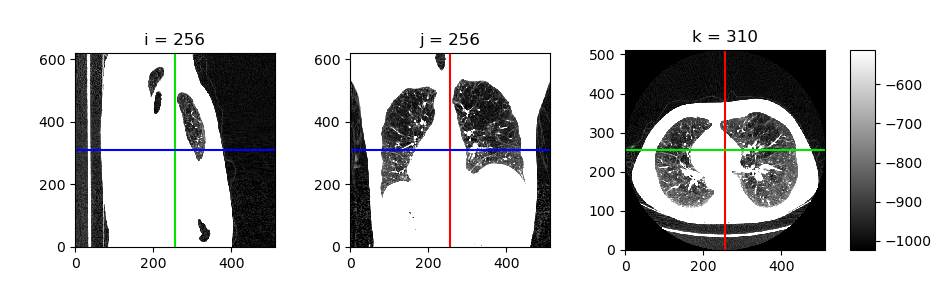

In [31]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, **img_kws)

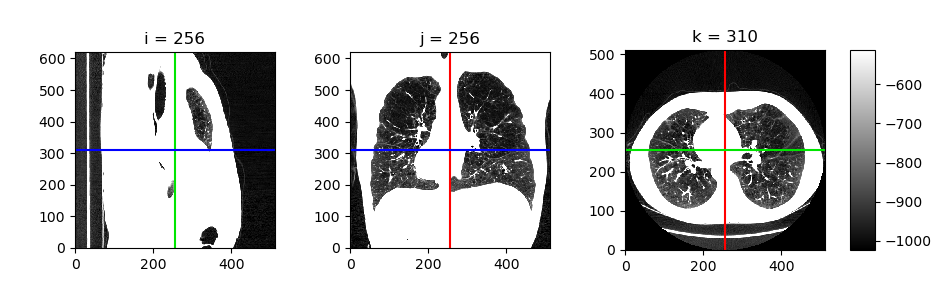

In [32]:
mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, **img_kws)

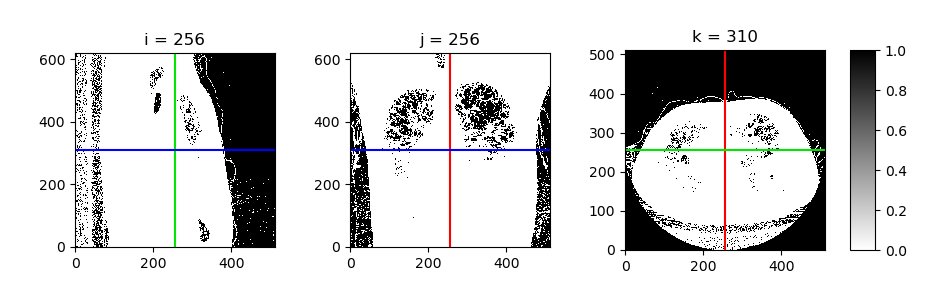

In [20]:
emph = (img0.get_fdata() <= -950)
mpl_viz.SliceViewer(emph, vox_spacing=spacing0, cmap='binary', vmin=0, vmax=1)

# Preprocessing tests

In [1]:
proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 2,5),
        'interpolation': 'linear',
        'default_value': -1024.
    },
    'image_segmentation': {
        'tasks': [
            {
                'task_name': 'total',
                'roi_subset': [
                    'lung_upper_lobe_right',
                    'lung_middle_lobe_right',
                    'lung_lower_lobe_right',
                    'lung_upper_lobe_left',
                    'lung_lower_lobe_left',
                ],
            },
            {
                'task_name': 'lung_vessels'
            },
            {
                'task_name': 'body'
            }
        ],
        'combine': True
    },
    'image_registration': {
        'method': 'unigradicon',
        'args': {
            'model': 'gradiconlung',
            'io_sim': 'lncc2',
            'io_iterations': 100, # 50
            'io_sigma': 1,
            'loss_function_masking': True,
            'intensity_conservation': True
        }
    },
    'region_labeling': {
        'roi_order': [
            'lung_upper_lobe_right',
            'lung_middle_lobe_right',
            'lung_lower_lobe_right',
            'lung_upper_lobe_left',
            'lung_lower_lobe_left',
        ],
        'region_filter': {
            'min_voxels': 30,
            'keep_largest': True
        }
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            'max_facet_distance': 0.75,
            'max_cell_circumradius': 5.0,
            'lloyd': True,
            'odt': True
        }
    },
    'mesh_interpolation': {}
}

In [33]:
%autoreload
import project.preprocessing.api as api

bin_path = '/ocean/projects/asc170022p/mtragoza/mambaforge/envs/warp/bin'
os.environ['PATH'] = bin_path + ':' + os.environ['PATH']

for ex in examples[:1]:
    api.preprocess_example(ex, proc_config)

print('Done')

INFO: ../../data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: ../../data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: ../../data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: ../../data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz exists; Skipping stage create_multi_region_map
INFO: ../../data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: ../../data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tseg_regions.nii.gz exists; Skipping stage create_multi_region_map
INFO: ../../data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_tseg_corr_INSP.nii.gz missing; Running stage register_displacement_field
Running uniGradICON registration
ICONLoss(all_loss=tensor(

construct initial points (nb_points: 12)
12/12 initial point(s) found...
Start surface scan...Scanning triangulation for bad facets (sequential) - number of finite facets = 53...
Number of bad facets: 21
scanning edges (lazy)
scanning vertices (lazy)
end scan. [Bad facets:21]

Refining Surface...
Legend of the following line: (#vertices,#steps,#facets to refine,#tets to refine)
(1263,1250,1324,0) (19441.8 vertices/s)

KeyboardInterrupt: 